Can we find distinct behavioral types of users who spread misinformation?

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the file
df = pd.read_csv("Features_For_Traditional_ML_Techniques.csv")

In [3]:
#define the features for behavioral clustering
features = [
    'followers_count', 'friends_count', 'favourites_count', 
    'statuses_count', 'BotScore', 'cred', 
    'normalize_influence', 'replies', 'retweets'
]

In [4]:
#drop rows with missing values in these columns to ensure clean clustering
df_clean = df.dropna(subset=features + ['BinaryNumTarget'])

In [5]:
# Extract features for clustering
X = df_clean[features]

# scale the Features (crucial for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K-Means

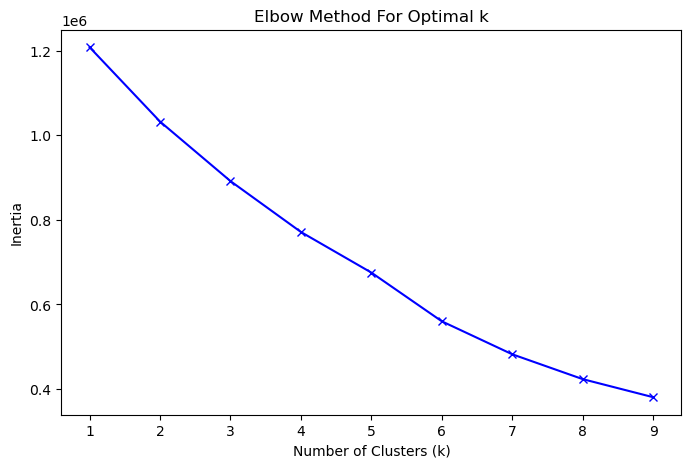

In [9]:
#using elbow method to find the optimal number of k
inertia = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.savefig("elbow_truth.png")
plt.show()


Analysis for K-Means (K=9):
        BinaryNumTarget        followers_count  BotScore normalize_influence  \
                   mean  count            mean      mean                mean   
Cluster                                                                        
0              0.452236  42323    7.104728e+01  0.025405            0.054094   
1              0.598524   6775    2.478700e+04  0.030412            0.107839   
2              0.508530  57383    9.794984e+02  0.029949            0.084295   
3              0.000000      1    1.012993e+06  0.030000            0.159002   
4              0.478221   4339    7.931989e+01  0.976100            0.027540   
5              1.000000      1    1.306019e+08  0.030000            0.208606   
6              0.604027    298    1.693679e+05  0.030000            0.139920   
7              0.619605  23076    4.792223e+04  0.029801            0.104154   
8              0.000000      2    3.976750e+04  0.030000            0.125554   

        Fa

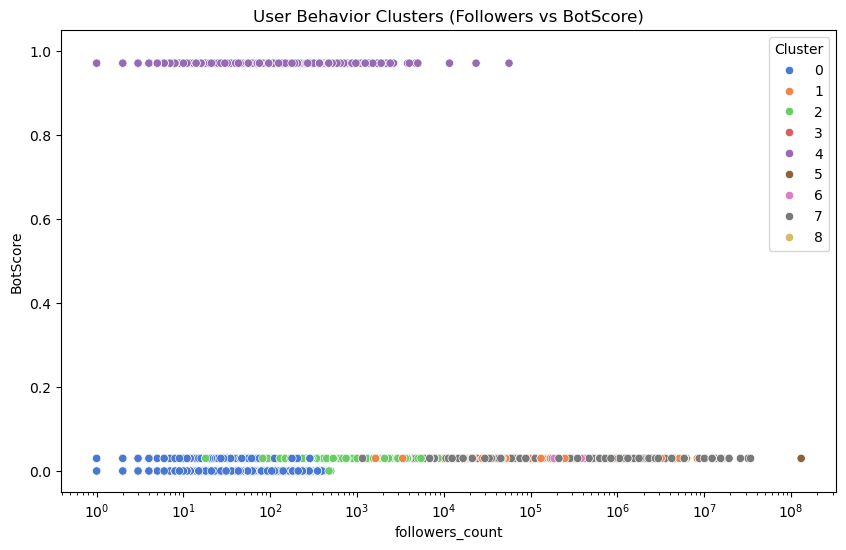

In [12]:
# Based on the elbow plot, pick a k.
optimal_k = 9 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"\nAnalysis for K-Means (K={optimal_k}):")

# Calculate average target (1=True, 0=False)
cluster_analysis = df_clean.groupby('Cluster').agg({
    'BinaryNumTarget': ['mean', 'count'],
    'followers_count': 'mean',
    'BotScore': 'mean',
    'normalize_influence': 'mean'
})

# Calculate percentage of fake news (lower mean = more fake news)
#Fake News Propensity is a metric we create to represent how likely 
#a cluster of users is to spread fake news, based on the historical data in our dataset.
# 0: The cluster spreads 100% True news.
# 1: The cluster spreads 100% Fake news.
cluster_analysis['FakeNewsPropensity'] = 1 - cluster_analysis[('BinaryNumTarget', 'mean')]

print(cluster_analysis)

# Visualization

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean, 
    x='followers_count', 
    y='BotScore', 
    hue='Cluster', 
    palette='muted'
)
plt.title('User Behavior Clusters (Followers vs BotScore)')
plt.xscale('log')
plt.savefig("FinalCluster.png")# Log scale handles huge variations in follower counts
plt.show()

Based on the analysis: 
Cluster 3 and 8 are highly suspicious with fake news propensity of 100%. But very small count.
Cluster 0,2,4 have fake news propensity of around 50%, and large count.
Cluster 5 has 0% fake news propensity (all people in this cluster only post true news) but also has a small count - just 1 person.

The data shows that misinformation isn't spread just by bots, but also by typical, low-influence users who may not have high algorithmic awareness.